In [20]:
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np

In [21]:
base_dir = Path("D:/Mitosis WSI CCMCT")
mitotic_dir = base_dir / "mitotic"
non_mitotic_dir = base_dir / "non_mitotic"

In [22]:
mitotic_files = list(mitotic_dir.glob('*.png'))
non_mitotic_files = list(non_mitotic_dir.glob('*.png'))

print(f"Mitotic: {len(mitotic_files)}, Non-Mitotic: {len(non_mitotic_files)}")
print(f"Imbalance Ratio: {(len(non_mitotic_files) / len(mitotic_files)):.3f}")

Mitotic: 21036, Non-Mitotic: 125194
Imbalance Ratio: 5.951


In [23]:
def visualize_patches(dir_path, label, num_samples=5):
    files = random.sample(list(dir_path.glob('*.png')),num_samples)
    fig,axs = plt.subplots(1,num_samples,figsize=(15, 3))
    for i,file in enumerate(files):
        img = cv2.imread(str(file))
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        axs[i].imshow(img)
        axs[i].set_title(f"{label} - {file.stem}")
        axs[i].axis('off')
    plt.show()

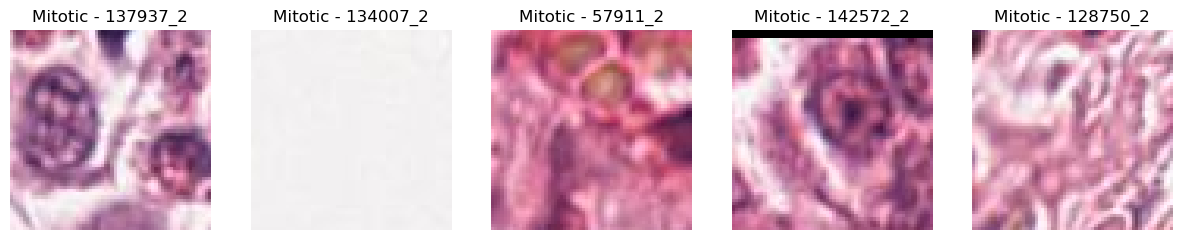

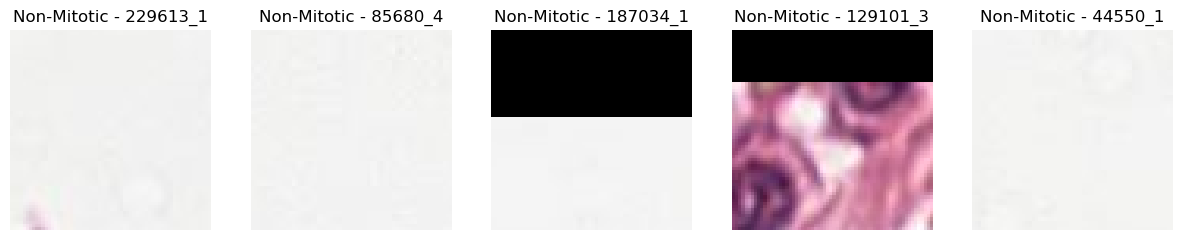

In [24]:
visualize_patches(mitotic_dir,"Mitotic")
visualize_patches(non_mitotic_dir, "Non-Mitotic")

In [25]:
def check_image_stats(files):
    shapes = []
    means = []
    for file in random.sample(files,min(100,len(files))):
        img = cv2.imread(str(file))
        if img is None:
            print(f"File {file} is Corrupted")
            continue
        shapes.append(img.shape)
        means.append(np.mean(img))

    unique_shapes = set(shapes)
    avg_mean = np.mean(means)
    print(f"Unique Shapes: {unique_shapes}, Avg Pixel Mean: {avg_mean:.2f}")

In [26]:
check_image_stats(mitotic_files)
check_image_stats(non_mitotic_files)

Unique Shapes: {(64, 64, 3)}, Avg Pixel Mean: 191.70
Unique Shapes: {(64, 64, 3)}, Avg Pixel Mean: 187.51


In [27]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import glob
from pathlib import Path

In [28]:
class Mitosis(Dataset):
    
    def __init__(self,root_dir,transform=None):
        self.transform = transform
        self.images = []
        self.labels = []

        mitotic_paths = glob.glob(str(base_dir / 'mitotic' / '*.png'))
        for path in mitotic_paths:
            self.images.append(path)
            self.labels.append(1)

        non_mitotic_paths = glob.glob(str(base_dir / 'non_mitotic' / '*.png'))
        for path in non_mitotic_paths:
            self.images.append(path)
            self.labels.append(0)

    def __len__(self):
        return len(self.images)

    def __getitem__(self,idx):
        img_path = self.images[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return img, label

In [29]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

In [30]:
full_dataset = Mitosis(base_dir,transform=transform)

train_size = int(0.1 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

In [31]:
print(type(train_dataset))

<class 'torch.utils.data.dataset.Subset'>


In [32]:
batch_size = 21

train_loader = DataLoader(train_dataset, batch_size=batch_size,shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size,shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size,shuffle=False)

In [33]:
print(type(train_loader))

<class 'torch.utils.data.dataloader.DataLoader'>


In [34]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import WeightedRandomSampler

In [35]:
import torchvision.models as models

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 8 * 8, 512) 
        self.fc2 = nn.Linear(512, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(-1, 128 * 8 * 8)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
# model = models.resnet18(pretrained=True).to(device)
# model.fc = nn.Linear(model.fc.in_features, 2).to(device)  # 2 classes: mitotic / non-mitotic

weights = [1.0, len(non_mitotic_files) / len(mitotic_files)] # Higher weight for mitotic
weights = torch.tensor(weights).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [36]:
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader):.4f}")
   
    # Validate
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Val Accuracy: {100 * correct / total:.4f}%")

    
# Save model
torch.save(model.state_dict(), base_dir / 'mitosis_model.pth')

Epoch 1, Loss: 0.7817
Val Accuracy: 86.0289%
Epoch 2, Loss: 0.6928
Val Accuracy: 86.0289%
Epoch 3, Loss: 0.6921
Val Accuracy: 86.0289%
Epoch 4, Loss: 0.6925
Val Accuracy: 86.0289%
Epoch 5, Loss: 0.6919
Val Accuracy: 13.9711%
Epoch 6, Loss: 0.6927
Val Accuracy: 86.0289%
Epoch 7, Loss: 0.6918
Val Accuracy: 86.0289%
Epoch 8, Loss: 0.6910
Val Accuracy: 86.0289%
Epoch 9, Loss: 0.6915
Val Accuracy: 86.0289%
Epoch 10, Loss: 0.6925
Val Accuracy: 86.0289%
